# osapiens Challenge Makeathon 2026 — Detecting Deforestation from Space

---

## Table of Contents

1. Data Download / Structure / Setup
2. Challenge: Detecting Deforestation from Space
3. Definition of Deforestation
4. Data Description & Visualisation
   - 4.1 Sentinel-2
   - 4.2 Sentinel-1
   - 4.3 AlphaEarth Foundations
5. Labels Description & Visualisation
   - 5.1 RADD Alert Labels
   - 5.2 GLAD-L Alert Labels
   - 5.3 GLAD-S2 Alert Labels
6. Submission
   - 6.1 Example: using `submission_utils.py`
7. Helpful Resources

## 1 — Data Download / Structure / Setup

> run `make download_data_from_s3` from your terminal to download data

After downloading, the dataset lives under `data/makeathon-challenge/` and is split into `train` and `test` sets across four top-level folders.

```
data/makeathon-challenge/
├── sentinel-1/
│   ├── train/{tile_id}__s1_rtc/{tile_id}__s1_rtc_{year}_{month}_{ascending|descending}.tif
│   └── test/  ...
├── sentinel-2/
│   ├── train/{tile_id}__s2_l2a/{tile_id}__s2_l2a_{year}_{month}.tif
│   └── test/  ...
├── aef-embeddings/
│   ├── train/{tile_id}_{year}.tiff
│   └── test/  ...
├── labels/train/
│   ├── gladl/   gladl_{tile_id}_alert{YY}.tif  +  gladl_{tile_id}_alertDate{YY}.tif
│   ├── glads2/  glads2_{tile_id}_alert.tif     +  glads2_{tile_id}_alertDate.tif
│   └── radd/    radd_{tile_id}_labels.tif
└── metadata/
    ├── train_tiles.geojson
    └── test_tiles.geojson
```

Each tile is identified by an ID of the form `{MGRS_grid}_{x}_{y}` (e.g. `18NWG_6_6`), encoding its position within a Military Grid Reference System tile. Sentinel-1 and Sentinel-2 are monthly time series; AlphaEarth embeddings are annual. Labels are only provided for the training set — the test set is used exclusively for leaderboard evaluation. Spatial coverage of all tiles is documented in the two GeoJSON files under `metadata/`.

**We want to emphasize that you are not required to use these specific data sources or labels in your solution.** You are free to incorporate any additional data sources or labels you find useful, as long as your final submission follows the required format and contains predictions only for the test set tiles. More on submission format in section 6.

## 2 — Challenge: Detecting Deforestation from Space

![deforestation](content/deforestation.png)
> The picture above shows a deforestation event in the Cerrado Region, Brazil captured by Sentinel-2 in September 2020.

As global deforestation continues, the EU Deforestation Regulation (EUDR) is driving demand for large-scale geospatial monitoring by requiring companies to verify that their supply chains are deforestation-free.

Satellite constellations monitor Earth at global scale using optical and radar sensors—but turning this data into reliable insights is difficult.

Satellite data is noisy, heterogeneous, and varies across sensors, regions, and environmental conditions.

As a result, deforestation detection systems often lack accuracy and generalization.

Building systems that can turn these imperfect signals into reliable, automated, and globally consistent evidence remains an open problem and the focus of this challenge.



## 3 — Definition of Deforestation

For this challenge, we focus exclusively on deforestation events occurring after 2020. Deforestation is defined as the permanent removal of tree cover, leading to a transition from forest to non-forest land. Accordingly, an event is only considered deforestation after 2020 if the area was forest in 2020.

## 4 — Data Description & Visualisation

In this challenge we have 3 data modalities (Sentinel-2, Sentinel-1, and AlphaEarth Foundations) and 3 weak-label sources (RADD, GLAD-L, and GLAD-S2). Each has different characteristics, strengths, and limitations. Understanding these is crucial for building effective models. In the sections below, we provide an overview of each data source, along with code snippets to load and visualize the data.

### 4.1 — Sentinel-2

Each pixel in the Sentinel-2 data contains 12 spectral bands, each capturing reflectance at different wavelengths. These bands provide complementary information about land cover, vegetation health, soil properties, and atmospheric conditions. Below is a summary of the Sentinel-2 bands included in the dataset:

| Band | Name / Type | Resolution (m/px) | Central Wavelength (nm) | Bandwidth (nm) | Description / Use |
|------|------------|-------------------|--------------------------|----------------|-------------------|
| B01 | Aerosol | 60 | 443 | 20 | Aerosol detection |
| B02 | Blue | 10 | 490 | 65 | Soil & vegetation discrimination, forest mapping, detects man-made features |
| B03 | Green | 10 | 560 | 35 | Water clarity contrast, vegetation reflectance, highlights oil |
| B04 | Red | 10 | 665 | 30 | Vegetation, soil, urban areas, strong reflection from dead foliage |
| B05 | Red Edge | 20 | 705 | 15 | Vegetation classification |
| B06 | Red Edge | 20 | 740 | 15 | Vegetation classification |
| B07 | Red Edge | 20 | 783 | 20 | Vegetation classification |
| B08 | NIR | 10 | 842 | 115 | Biomass, vegetation analysis, shoreline mapping |
| B8A | Narrow NIR | 20 | 865 | 20 | Vegetation classification |
| B09 | Water Vapour | 60 | 945 | 20 | Water vapour detection |
| B10 | Cirrus | 60 | 1375 | 30 | Cirrus cloud detection |
| B11 | SWIR 1 | 20 | 1610 | 90 | Moisture content, vegetation contrast, snow vs cloud differentiation |
| B12 | SWIR 2 | 20 | 2190 | 180 | Moisture content, vegetation contrast, snow vs cloud differentiation |

Source: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/bands/

All bands are provided in a single multi-band `.tif` file and are upsampled to 10m resolution for consistency. The data is delivered in a local UTM projected CRS. Observations are not mosaicked and represent the single best cloud-free scene for a given month. When combining with other rasters (e.g. labels), ensure all files are reprojected to the same CRS to guarantee proper alignment.

In [1]:
import numpy as np
import rasterio

S2_PATH    = "data/makeathon-challenge/sentinel-2/train/18NWG_6_6__s2_l2a/18NWG_6_6__s2_l2a_2020_1.tif"
ALERT_PATH = "data/makeathon-challenge/labels/train/glads2/glads2_18NWG_6_6_alert.tif"

with rasterio.open(S2_PATH) as src:
    print("Tile: 18NWG_6_6 | Year: 2020 | Month: January")
    print(f"Number of bands : {src.count}")  # all 12 spectral bands present; we render only RGB (B4, B3, B2)
    print(f"Dtype           : {src.dtypes[0]}")
    print(f"CRS             : {src.crs}")
    print(f"Shape           : {src.shape}")


Tile: 18NWG_6_6 | Year: 2020 | Month: January
Number of bands : 12
Dtype           : uint16
CRS             : EPSG:32618
Shape           : (1002, 1002)


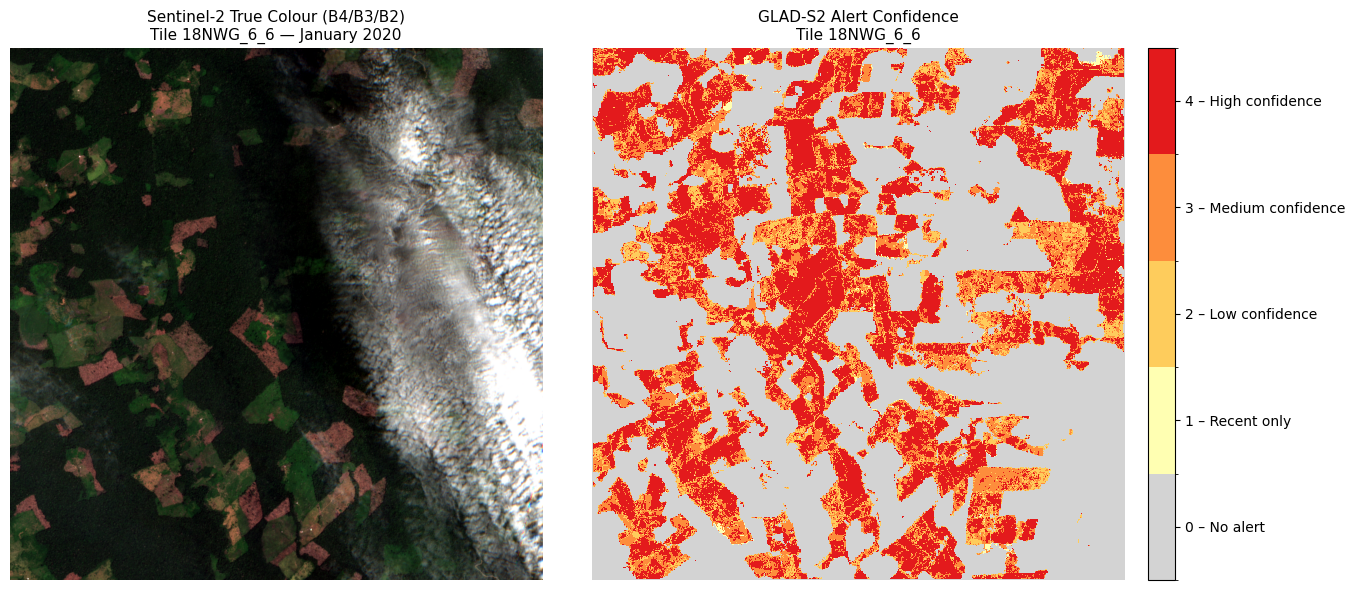

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from rasterio.warp import reproject, Resampling

# Load Sentinel-2 RGB bands: B4 = Red (index 4), B3 = Green (index 3), B2 = Blue (index 2)
with rasterio.open(S2_PATH) as src:
    red   = src.read(4).astype(np.float32)
    green = src.read(3).astype(np.float32)
    blue  = src.read(2).astype(np.float32)
    s2_transform = src.transform
    s2_crs       = src.crs
    s2_shape     = src.shape

def percentile_normalise(band, p_lo=2, p_hi=98):
    valid = band[band > 0]
    lo, hi = np.percentile(valid, [p_lo, p_hi])
    return np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)

rgb = np.stack(
    [percentile_normalise(red), percentile_normalise(green), percentile_normalise(blue)],
    axis=-1,
)

# Reproject GLAD-S2 alert (EPSG:4326) onto the Sentinel-2 grid (UTM)
with rasterio.open(ALERT_PATH) as src:
    alert_reproj = np.zeros(s2_shape, dtype=np.uint8)
    reproject(
        source=src.read(1),
        destination=alert_reproj,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=s2_transform,
        dst_crs=s2_crs,
        resampling=Resampling.nearest,
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(rgb)
axes[0].set_title("Sentinel-2 True Colour (B4/B3/B2)\nTile 18NWG_6_6 — January 2020", fontsize=11)
axes[0].axis("off")

cmap = mcolors.ListedColormap(["#d3d3d3", "#ffffb2", "#fecc5c", "#fd8d3c", "#e31a1c"])
norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

im = axes[1].imshow(alert_reproj, cmap=cmap, norm=norm, interpolation="nearest")
axes[1].set_title("GLAD-S2 Alert Confidence\nTile 18NWG_6_6", fontsize=11)
axes[1].axis("off")

cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(
    ["0 – No alert", "1 – Recent only", "2 – Low confidence", "3 – Medium confidence", "4 – High confidence"]
)

plt.tight_layout()
plt.show()


### 4.2 — Sentinel-1

Sentinel-1 is a radar satellite that provides all-weather (can penetrate clouds), day-and-night imaging capabilities. It captures the Earth's surface using microwave signals, which are reflected back to the satellite. The dataset includes 1 radar backscatter channel with VV polarisation. You can read more about Sentinel-1 Mission here: https://sentiwiki.copernicus.eu/web/s1-mission

Sentinel-1 data is available at multiple processing levels. For this challenge, we provide the highest standard: **Radiometrically Terrain Corrected (RTC)** product. Measurements have been preprocessed to correct for terrain-induced distortions and radiometric effects, making them ready for direct analysis and modeling.

The data is delivered in a local UTM projected coordinate reference system (CRS), aligned with Sentinel-2. When combining these data with other rasters (e.g., labels), ensure that all datasets are reprojected to the same CRS to guarantee proper spatial alignment.


In [3]:
S1_PATH = "data/makeathon-challenge/sentinel-1/train/18NWG_6_6__s1_rtc/18NWG_6_6__s1_rtc_2020_10_ascending.tif"

with rasterio.open(S1_PATH) as src:
    print("Tile: 18NWG_6_6 | Year: 2020 | Month: October | Orbit: ascending")
    print(f"Number of bands : {src.count}")  # 1 band — VV polarisation (linear scale)
    print(f"Dtype           : {src.dtypes[0]}")
    print(f"CRS             : {src.crs}")
    print(f"Shape           : {src.shape}")


Tile: 18NWG_6_6 | Year: 2020 | Month: October | Orbit: ascending
Number of bands : 1
Dtype           : float32
CRS             : EPSG:32618
Shape           : (334, 335)


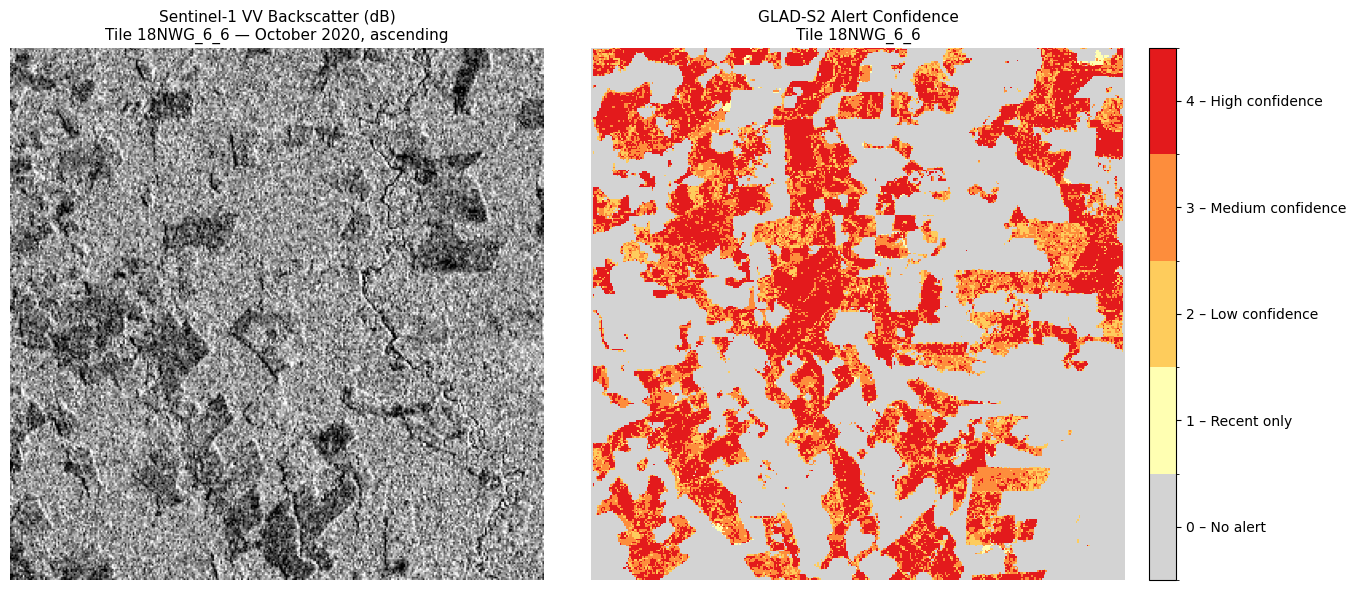

In [4]:
with rasterio.open(S1_PATH) as src:
    backscatter  = src.read(1).astype(np.float32)
    s1_transform = src.transform
    s1_crs       = src.crs
    s1_shape     = src.shape

# Convert linear backscatter to dB and normalise for display
db = np.where(backscatter > 0, 10 * np.log10(backscatter), np.nan)
valid = db[np.isfinite(db)]
lo, hi = np.percentile(valid, [2, 98])
s1_display = np.nan_to_num(np.clip((db - lo) / (hi - lo + 1e-6), 0, 1), nan=0.0)

# Reproject GLAD-S2 alert onto the S1 grid
with rasterio.open(ALERT_PATH) as src:
    alert_s1 = np.zeros(s1_shape, dtype=np.uint8)
    reproject(
        source=src.read(1),
        destination=alert_s1,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=s1_transform,
        dst_crs=s1_crs,
        resampling=Resampling.nearest,
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(s1_display, cmap="gray")
axes[0].set_title("Sentinel-1 VV Backscatter (dB)\nTile 18NWG_6_6 — October 2020, ascending", fontsize=11)
axes[0].axis("off")

cmap_alert = mcolors.ListedColormap(["#d3d3d3", "#ffffb2", "#fecc5c", "#fd8d3c", "#e31a1c"])
norm_alert = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap_alert.N)

im = axes[1].imshow(alert_s1, cmap=cmap_alert, norm=norm_alert, interpolation="nearest")
axes[1].set_title("GLAD-S2 Alert Confidence\nTile 18NWG_6_6", fontsize=11)
axes[1].axis("off")

cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(
    ["0 – No alert", "1 – Recent only", "2 – Low confidence", "3 – Medium confidence", "4 – High confidence"]
)

plt.tight_layout()
plt.show()


### 4.3 — AlphaEarth Foundations (EPSG:4326)

AlphaEarth Foundations is a global dataset of pre-trained embeddings derived from multiple satellite data sources, including Sentinel-2 and Sentinel-1. These embeddings are designed to capture rich spatio-temporal patterns in the data, providing a powerful representation for downstream tasks like deforestation detection.

The dataset is organized into tiles that cover the same spatial extent as the Sentinel-2 and Sentinel-1 data, but is delivered in a geodetic coordinate reference system (CRS) of EPSG:4326 (WGS-84). This means that the pixel coordinates are defined in terms of latitude and longitude, rather than projected coordinates like UTM. When using the AlphaEarth Foundations embeddings in conjunction with the Sentinel-2 and Sentinel-1 data, it is crucial to reproject the embeddings to the same CRS (local UTM) to ensure proper spatial alignment before modeling. This can be done using geospatial libraries such as `rasterio` or `GDAL`, which allow for efficient reprojection of raster data while preserving the integrity of the embeddings.


Paper: https://arxiv.org/abs/2507.22291


In [5]:
AEF_PATH = "data/makeathon-challenge/aef-embeddings/train/18NWG_6_6_2020.tiff"

with rasterio.open(AEF_PATH) as src:
    print("Tile: 18NWG_6_6 | Year: 2020")
    print(f"Number of bands : {src.count}")  # 64 embedding dimensions; we display 3 randomly chosen bands as RGB
    print(f"Dtype           : {src.dtypes[0]}")
    print(f"CRS             : {src.crs}")
    print(f"Shape           : {src.shape}")


Tile: 18NWG_6_6 | Year: 2020
Number of bands : 64
Dtype           : float32
CRS             : EPSG:4326
Shape           : (1004, 998)


Randomly selected bands (1-indexed): [6, 42, 49]


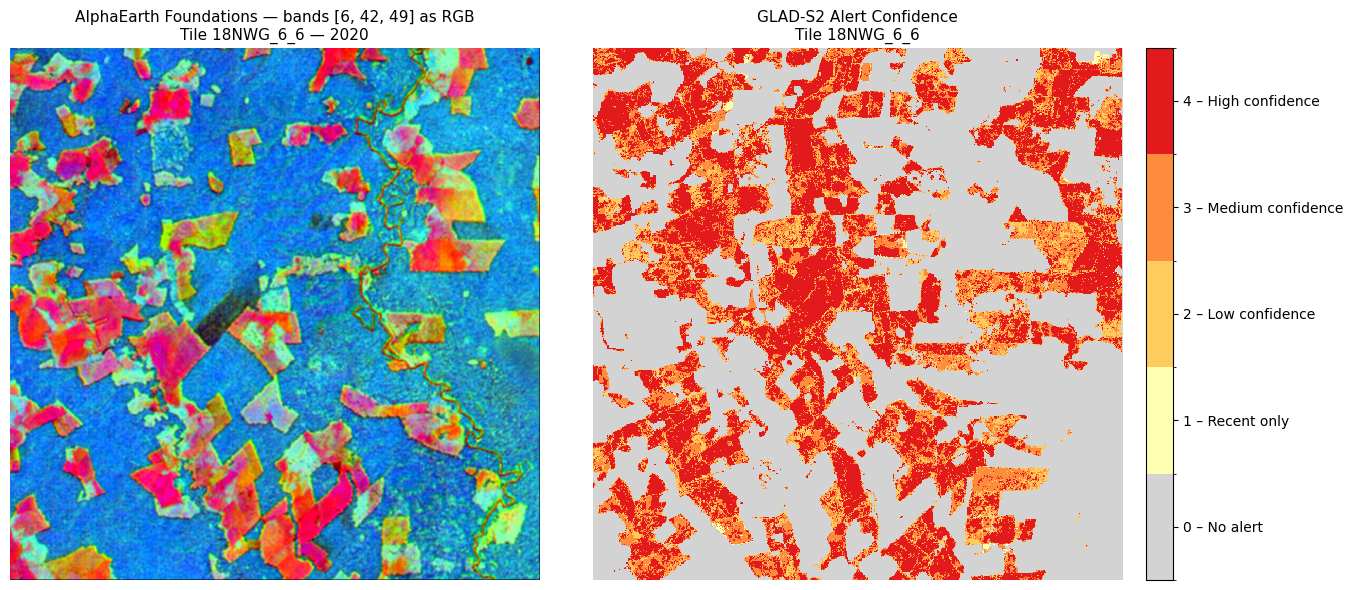

In [6]:
rng = np.random.default_rng(seed=42)
chosen = sorted(rng.choice(64, size=3, replace=False).tolist())
print(f"Randomly selected bands (1-indexed): {[b + 1 for b in chosen]}")

with rasterio.open(AEF_PATH) as src:
    aef_data     = src.read([b + 1 for b in chosen]).astype(np.float32)
    aef_transform = src.transform
    aef_crs       = src.crs
    aef_shape     = src.shape

def normalise_nan(band, p_lo=2, p_hi=98):
    valid = band[np.isfinite(band)]
    lo, hi = np.percentile(valid, [p_lo, p_hi])
    return np.nan_to_num(np.clip((band - lo) / (hi - lo + 1e-6), 0, 1), nan=0.0)

aef_rgb = np.stack([normalise_nan(aef_data[i]) for i in range(3)], axis=-1)

# Both AEF and GLAD-S2 are in EPSG:4326 — resample alert onto the AEF grid
with rasterio.open(ALERT_PATH) as src:
    alert_aef = np.zeros(aef_shape, dtype=np.uint8)
    reproject(
        source=src.read(1),
        destination=alert_aef,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=aef_transform,
        dst_crs=aef_crs,
        resampling=Resampling.nearest,
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(aef_rgb)
axes[0].set_title(
    f"AlphaEarth Foundations — bands {[b + 1 for b in chosen]} as RGB\nTile 18NWG_6_6 — 2020",
    fontsize=11,
)
axes[0].axis("off")

cmap_alert = mcolors.ListedColormap(["#d3d3d3", "#ffffb2", "#fecc5c", "#fd8d3c", "#e31a1c"])
norm_alert = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap_alert.N)

im = axes[1].imshow(alert_aef, cmap=cmap_alert, norm=norm_alert, interpolation="nearest")
axes[1].set_title("GLAD-S2 Alert Confidence\nTile 18NWG_6_6", fontsize=11)
axes[1].axis("off")

cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(
    ["0 – No alert", "1 – Recent only", "2 – Low confidence", "3 – Medium confidence", "4 – High confidence"]
)

plt.tight_layout()
plt.show()


## 5 — Labels Description and Encodings

The challenge includes three sources of weak\* labels for deforestation: RADD, GLAD-L, and GLAD-S2. Each label source has different characteristics, strengths, and limitations. Below we provide an overview of each label type, along with code snippets to load and visualize the labels.

\*By weak labels, we mean that these are not perfect ground truth (predictions in fact), but rather noisy indicators of deforestation events. They can be used for training and evaluation, but it's important to understand their limitations and potential biases when interpreting model performance.


### 5.1 — RADD (Radar for Detecting Deforestation) Alert Labels

RADD is a state-of-the-art deforestation detection system that uses Sentinel-1 radar data to identify deforestation events. RADD generates binary alert masks indicating areas of potential deforestation, along with confidence scores for each alert.

We provide the alerts in it's rawest form meaning there was no post-processing was done from our side.

Here is everything you should know to understand the RADD labels:

Source files:

- one raw tile TIFF per dataset tile

Encoding:

- one integer encodes both confidence and alert date
- leading digit:
    - `2` = low confidence
    - `3` = high confidence
- remaining digits:
    - number of days since `2014-12-31`
- `0` = no alert

Examples:

- `20001` = low-confidence alert on `2015-01-01`
- `30055` = high-confidence alert on `2015-02-24`
- `21847` = low-confidence alert on `2020-01-21`


### 5.2 — GLAD-L (Global Land Analysis & Discovery — Landsat) Alert Labels

GLAD-L is a deforestation alert system that uses Landsat optical data to identify potential deforestation events. Similar to RADD, GLAD-L generates binary alert masks and alert-date rasters, but with different confidence encoding and known limitations.

Here is everything you should know to understand the GLAD-L labels:

Source files:

- `alertYY.tif`
- `alertDateYY.tif`

Examples:

- `alert24.tif`
- `alertDate24.tif`

Encoding:

- `alertYY` is a raw yearly alert raster, usually `uint8`
    - `0` = no loss
    - `2` = probable loss
    - `3` = confirmed loss
- `alertDateYY` is a raw yearly alert-date raster, usually `uint16`
    - value = day-of-year within year `20YY`
    - `0` = no alert

### 5.3 — GLAD-S2 (Global Land Analysis & Discovery — Sentinel-2) Alert Labels

GLAD-S2 is a deforestation alert system that uses Sentinel-2 optical data to identify potential deforestation events. It provides similar outputs to GLAD-L, but with different confidence encoding and known limitations.

Here is everything you should know to understand the GLAD-S2 labels:

Source files:

- `alert.tif`
- `alertDate.tif`

Encoding:

- `alert` is a raw confidence raster, usually `uint8`
    - `0` = no loss
    - `1` = loss detected only in the most recent observation
    - `2` = low confidence loss
    - `3` = medium confidence loss
    - `4` = high confidence loss
- `alertDate` is a raw day-offset raster, usually `uint16`
    - value = number of days since `2019-01-01`
    - `0` = no alert

*Note*: Compared to GLAD-L, GLAD-S2 includes all years in a single raster that is why YY is not included in the file names.

## 6 — Submission


### 6.1 — Example: using `submission_utils.py`

> Walk-through of how to convert a binary prediction raster into the submittable format using the provided utility script.

In [7]:
import sys, tempfile
from pathlib import Path

import geopandas as gpd
import numpy as np
import rasterio

sys.path.insert(0, ".")
from submission_utils import raster_to_geojson

PRED_PATH   = "data/makeathon-challenge/labels/train/radd/radd_18NWG_6_6_labels.tif"
OUTPUT_PATH = "submission/pred_18NWG_6_6.geojson"

# --- 1. Binarise: any non-zero predicted value encodes a deforestation alert ---
with rasterio.open(PRED_PATH) as src:
    pred = src.read(1)
    meta = src.meta.copy()

binary = (pred > 0).astype(np.uint8)
meta.update(dtype="uint8", nodata=0)

with tempfile.NamedTemporaryFile(suffix=".tif", delete=False) as tmp:
    tmp_path = tmp.name
with rasterio.open(tmp_path, "w", **meta) as dst:
    dst.write(binary, 1)

# --- 2. Convert binary raster → GeoJSON in EPSG:4326 via submission_utils ---
Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)
geojson = raster_to_geojson(tmp_path, output_path=OUTPUT_PATH)
Path(tmp_path).unlink()
print(f"GeoJSON saved to: {OUTPUT_PATH}")

# --- 3. Statistics (areas computed in a projected UTM CRS) ---
gdf     = gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")
gdf_utm = gdf.to_crs(gdf.estimate_utm_crs())
gdf_utm["area_ha"] = gdf_utm.area / 10_000

print(f"\nDeforestation statistics — tile 18NWG_6_6")
print(f"  Number of polygons : {len(gdf_utm)}")
print(f"  Total area         : {gdf_utm['area_ha'].sum():.2f} ha")
print(f"  Min polygon size   : {gdf_utm['area_ha'].min():.4f} ha")
print(f"  Max polygon size   : {gdf_utm['area_ha'].max():.2f} ha")
print(f"  Avg polygon size   : {gdf_utm['area_ha'].mean():.4f} ha")


Warning 1: DeprecationWarning: 'Memory' driver is deprecated since GDAL 3.11. Use 'MEM' onwards. Further messages of this type will be suppressed.


GeoJSON saved to: submission/pred_18NWG_6_6.geojson

Deforestation statistics — tile 18NWG_6_6
  Number of polygons : 106
  Total area         : 3431.28 ha
  Min polygon size   : 0.5165 ha
  Max polygon size   : 811.46 ha
  Avg polygon size   : 32.3706 ha


## 7 — Helpful Resources

- QGIS for desktop visualization of the rasters (.tif files) or polygons (.geojson files)
- Python libraries: Geopandas (vector data), Rasterio (raster data)